# MNIST One-Class / One-vs-Rest Outlier Detection

**Goal:** treat one digit as **normal** and all others as **outliers**, then train a detector (typically on normal-only) and evaluate on a mixed test set.

**Conventions**
- `y = 0` → normal
- `y = 1` → outlier
- higher anomaly score → more anomalous

**Make it modifiable**
- Set `NORMAL_DIGITS = [0]` (or any digit list) to change what is "normal".


> This VAE is deliberately small and trains for a few epochs for speed.

In [ ]:
!pip -q install -r ../requirements.txt

In [1]:
import sys
sys.path.append('..')
from common.utils import *

## Data

In [2]:
import os
import numpy as np
from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

from common.utils import set_global_seed

# --- Config ---
SEED = 42
DATA_DIR = "./data"
VAL_SIZE = 0.2

MAX_TRAIN_NORMAL = 20000   # (removed stray "2" line that was in the notebook)
MAX_VAL_TOTAL = 8000
MAX_TEST_TOTAL = 10000
BATCH_SIZE = 256

set_global_seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

tfm = transforms.ToTensor()
train_full = datasets.MNIST(root=DATA_DIR, train=True, download=True, transform=tfm)
test_full  = datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=tfm)

Xtr_all = train_full.data.numpy().astype(np.float32) / 255.0
ytr_all = train_full.targets.numpy().astype(int)
Xte_all = test_full.data.numpy().astype(np.float32) / 255.0
yte_all = test_full.targets.numpy().astype(int)

rng = np.random.default_rng(SEED)

def to_loader(X, batch_size, shuffle):
    Xf = X.reshape(len(X), -1)  # [N,784]
    ds = TensorDataset(torch.from_numpy(Xf))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)

def build_splits(normal_digit: int):
    """
    Builds train/val/test for one-vs-rest:
      - train: normal-only (digit==normal_digit)
      - val: normal + balanced outliers
      - test: full test set, y_test=1 for outliers
    Returns:
      train_loader, val_loader, test_loader,
      y_val, y_test, n_train_normals
    """
    NORMAL_DIGITS = [normal_digit]

    # normal-only pool from training set
    normal_mask = np.isin(ytr_all, NORMAL_DIGITS)
    X_normal = Xtr_all[normal_mask]

    X_train_n, X_val_n = train_test_split(
        X_normal, test_size=VAL_SIZE, random_state=SEED, shuffle=True
    )

    if MAX_TRAIN_NORMAL is not None:
        X_train_n = X_train_n[:MAX_TRAIN_NORMAL]
    if MAX_VAL_TOTAL is not None:
        X_val_n = X_val_n[:MAX_VAL_TOTAL]

    # validation outliers from non-normal training pool (random sample)
    out_mask = ~np.isin(ytr_all, NORMAL_DIGITS)
    X_out_pool = Xtr_all[out_mask]
    n_val_out = min(len(X_out_pool), len(X_val_n))
    out_idx = rng.permutation(len(X_out_pool))[:n_val_out]
    X_val_out = X_out_pool[out_idx]

    X_val = np.concatenate([X_val_n, X_val_out], axis=0)
    y_val = np.concatenate(
        [np.zeros(len(X_val_n), dtype=int), np.ones(len(X_val_out), dtype=int)],
        axis=0
    )

    # test mix (full MNIST test mapped to normal/outlier)
    X_test = Xte_all
    y_test = (~np.isin(yte_all, NORMAL_DIGITS)).astype(int)

    if MAX_TEST_TOTAL is not None:
        X_test = X_test[:MAX_TEST_TOTAL]
        y_test = y_test[:MAX_TEST_TOTAL]

    train_loader = to_loader(X_train_n, BATCH_SIZE, True)
    val_loader   = to_loader(X_val, BATCH_SIZE, False)
    test_loader  = to_loader(X_test, BATCH_SIZE, False)

    return train_loader, val_loader, test_loader, y_val, y_test, len(X_train_n)


Device: cuda


## VAE Model

In [3]:
from tqdm.auto import tqdm

INPUT_DIM = 784
HIDDEN = 256
LATENT = 16
BETA = 1.0  # KL weight; keep 1.0 for standard VAE
EPOCHS = 5  # small for speed
LR = 1e-3

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(INPUT_DIM, HIDDEN),
            nn.ReLU(),
            nn.Linear(HIDDEN, HIDDEN),
            nn.ReLU(),
        )
        self.mu = nn.Linear(HIDDEN, LATENT)
        self.logvar = nn.Linear(HIDDEN, LATENT)

        self.dec = nn.Sequential(
            nn.Linear(LATENT, HIDDEN),
            nn.ReLU(),
            nn.Linear(HIDDEN, HIDDEN),
            nn.ReLU(),
            nn.Linear(HIDDEN, INPUT_DIM),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        xhat = self.dec(z)
        return xhat, mu, logvar

def vae_loss(x, xhat, mu, logvar, beta=1.0):
    # summed over batch; printed as per-sample later
    recon = nn.functional.binary_cross_entropy(xhat, x, reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kl, recon, kl

def train_vae(train_loader, n_train: int):
    model = VAE().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)

    model.train()
    for epoch in range(1, EPOCHS + 1):
        total = 0.0
        for (xb,) in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
            xb = xb.to(device)
            opt.zero_grad()
            xhat, mu, logvar = model(xb)
            loss, recon, kl = vae_loss(xb, xhat, mu, logvar, beta=BETA)
            loss.backward()
            opt.step()
            total += loss.item()
        print(f"Epoch {epoch}: train loss per sample = {total / n_train:.4f}")

    return model


/home/rtatang/stats489/Disfussion_Model_for_Anomaly_Detection/outlier_mnist_models/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Scoring + Evaluation


------------------------------------------------------------
Normal digit = 0 | Training VAE on normals only (n_train=4738)


Epoch 1/5: 100%|██████████| 19/19 [00:00<00:00, 29.25it/s]


Epoch 1: train loss per sample = 361.2531


Epoch 2/5: 100%|██████████| 19/19 [00:00<00:00, 224.66it/s]


Epoch 2: train loss per sample = 210.8395


...

Epoch 3: train loss per sample = 163.8751


Epoch 4/5: 100%|██████████| 19/19 [00:00<00:00, 155.92it/s]


Epoch 4: train loss per sample = 159.9745


Epoch 5/5: 100%|██████████| 19/19 [00:00<00:00, 130.37it/s]


Epoch 5: train loss per sample = 156.8034


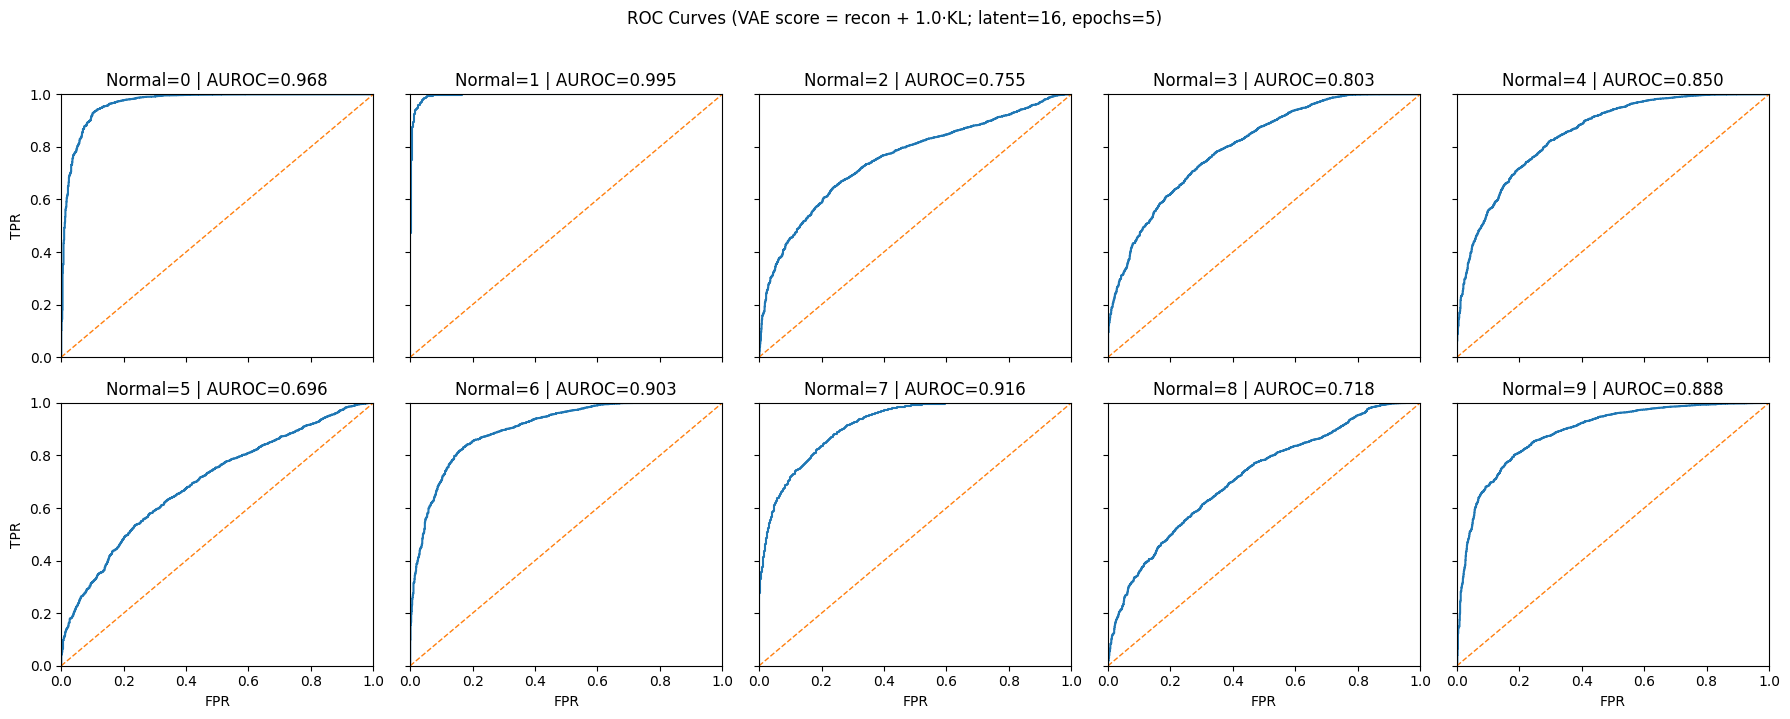

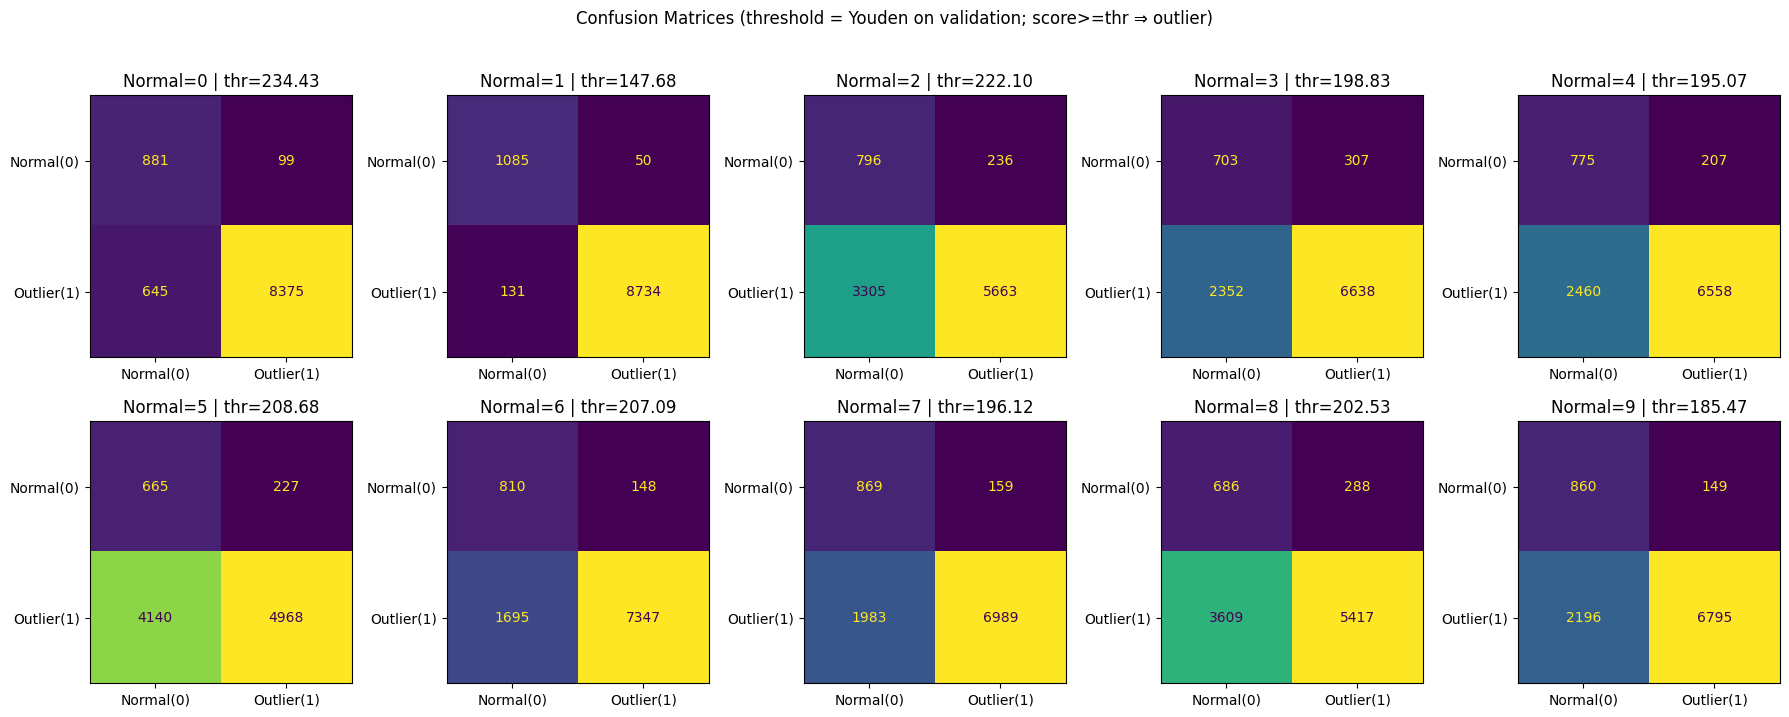

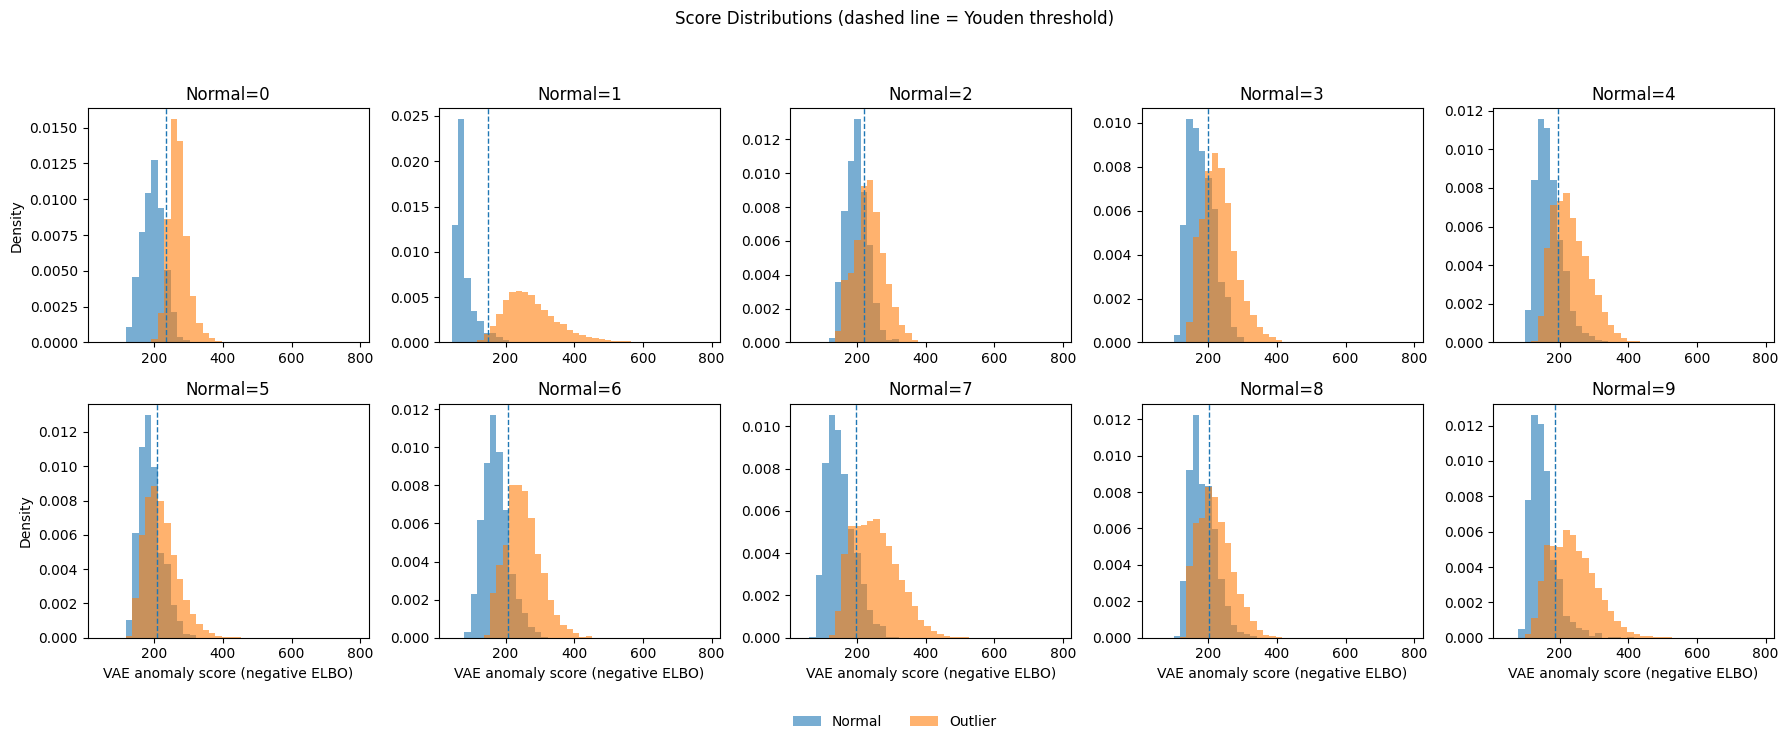

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

@torch.no_grad()
def score_loader(model, loader):
    """
    Per-sample anomaly score = negative ELBO:
      score(x) = recon(x) + BETA * KL(x)

    recon(x): per-sample BCE reconstruction error (sum over pixels)
    KL(x):    per-sample KL divergence term
    """
    model.eval()
    scores = []
    for (xb,) in loader:
        xb = xb.to(device)
        xhat, mu, logvar = model(xb)

        # per-sample recon term (sum over features)
        recon = nn.functional.binary_cross_entropy(xhat, xb, reduction="none").sum(dim=1)

        # per-sample KL term
        kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)

        # negative ELBO (higher => more anomalous)
        score = recon + BETA * kl
        scores.append(score.detach().cpu().numpy())

    return np.concatenate(scores, axis=0)

def choose_threshold_youden(y_true, scores):
    fpr, tpr, thr = roc_curve(y_true, scores)
    j = tpr - fpr
    return thr[np.argmax(j)]

def run_one(normal_digit: int):
    train_loader, val_loader, test_loader, y_val, y_test, n_train = build_splits(normal_digit)

    print("\n" + "-"*60)
    print(f"Normal digit = {normal_digit} | Training VAE on normals only (n_train={n_train})")

    model = train_vae(train_loader, n_train=n_train)

    scores_val  = score_loader(model, val_loader)
    scores_test = score_loader(model, test_loader)

    auroc = roc_auc_score(y_test, scores_test)
    fpr, tpr, _ = roc_curve(y_test, scores_test)

    thr = choose_threshold_youden(y_val, scores_val)
    y_hat = (scores_test >= thr).astype(int)
    cm = confusion_matrix(y_test, y_hat, labels=[0, 1])

    return fpr, tpr, auroc, cm, scores_test, y_test, thr

# ----------------------------
# Run all digits 0..9
# ----------------------------
results = []
for d in range(10):
    results.append((d, *run_one(d)))

# ----------------------------
# 1) ROC curves / AUROC (2x5)
# ----------------------------
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True, sharey=True)
axes = axes.ravel()

for i, (d, fpr, tpr, auroc, cm, scores_test, y_test, thr) in enumerate(results):
    ax = axes[i]
    ax.plot(fpr, tpr)
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_title(f"Normal={d} | AUROC={auroc:.3f}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    if i % 5 == 0:
        ax.set_ylabel("TPR")
    if i >= 5:
        ax.set_xlabel("FPR")

fig.suptitle(f"ROC Curves (VAE score = recon + {BETA}·KL; latent={LATENT}, epochs={EPOCHS})", y=1.02)
fig.tight_layout()

# ----------------------------
# 2) Confusion matrices (2x5)
# ----------------------------
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.ravel()

for i, (d, fpr, tpr, auroc, cm, scores_test, y_test, thr) in enumerate(results):
    ax = axes[i]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal(0)", "Outlier(1)"])
    disp.plot(ax=ax, colorbar=False, values_format="d")
    ax.set_title(f"Normal={d} | thr={thr:.2f}")
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle("Confusion Matrices (threshold = Youden on validation; score>=thr ⇒ outlier)", y=1.02)
fig.tight_layout()

# ----------------------------
# 3) Score distributions (2x5)
# ----------------------------
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.ravel()

all_scores = np.concatenate([r[5] for r in results])  # scores_test across digits
bins = np.histogram_bin_edges(all_scores, bins=40)

for i, (d, fpr, tpr, auroc, cm, scores_test, y_test, thr) in enumerate(results):
    ax = axes[i]
    s_norm = scores_test[y_test == 0]
    s_out  = scores_test[y_test == 1]

    ax.hist(s_norm, bins=bins, alpha=0.6, density=True, label="Normal")
    ax.hist(s_out,  bins=bins, alpha=0.6, density=True, label="Outlier")
    ax.axvline(thr, linestyle="--", linewidth=1)

    ax.set_title(f"Normal={d}")
    if i % 5 == 0:
        ax.set_ylabel("Density")
    if i >= 5:
        ax.set_xlabel("VAE anomaly score (negative ELBO)")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)

fig.suptitle("Score Distributions (dashed line = Youden threshold)", y=1.04)
fig.tight_layout(rect=[0, 0.06, 1, 1])
